# R-squared and Adjusted R-squared - Quick Revision Notes

These are **regression performance metrics**. They help us check how well a model predicts a number, such as a house price.

## 1. Why do we need a score?

After training a model, we need to check whether its predictions are close to the actual answers.

- A **residual** is the difference between the actual value and the predicted value.
- A small residual means the model made a small mistake.
- R-squared compares our model with a simple method that predicts the **average** target value for every row.
- If our model is better than this average-value method, it is learning useful patterns from the data.

## 2. R-squared ($R^2$)

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Where:

$$SS_{res} = \sum(y_i - \hat{y}_i)^2$$

$$SS_{tot} = \sum(y_i - \bar{y})^2$$

- $y_i$: real value.
- $\hat{y}_i$: predicted value.
- $\bar{y}$: average of all real values.
- $SS_{res}$: total squared mistakes made by the model.
- $SS_{tot}$: total squared distance from the average baseline.

## 3. Read $R^2$ in simple English

- $R^2 = 1$: perfect predictions on this data.
- $R^2 = 0$: no better than always predicting the average.
- $R^2 = 0.70$: the model explains about **70% of the variation** in the target.
- $R^2 < 0$: worse than always predicting the average.

**Important:** $R^2 = 0.70$ is **not** “70% accuracy.” Accuracy is mainly used for classification. Higher $R^2$ is usually better, but always check it on unseen test data too.

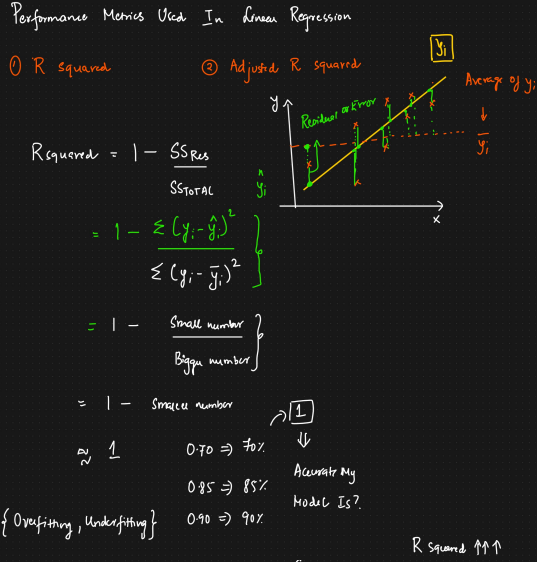

## 4. The problem with ordinary $R^2$

When we add more input features, ordinary $R^2$ can only stay the same or increase on the training data.

Example: house size and rooms are useful for price. Adding a random column such as a row number may make $R^2$ look a tiny bit better, even though that column does not truly help predict price. This can make the model look better than it really is.

## 5. Adjusted R-squared

$$R^2_{adjusted} = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}$$

- $n$: number of data rows/ Data Points.
- $p$: number of input features.

Adjusted $R^2$ adds a small penalty for every extra feature. It increases only when a new feature improves the model enough to earn its place.

| If you add a feature... | Ordinary $R^2$ | Adjusted $R^2$ |
|---|---|---|
| that truly helps | may increase | usually increases |
| that is useless | may still increase a little | can decrease |

For models with several features, use Adjusted $R^2$ alongside $R^2$ when comparing models.

## Visual diagram

Run the next cell. Left: green vertical lines are residuals - the model's mistakes. The orange dashed line is the lazy average baseline. Right: adding a useful feature helps both scores, but adding a random feature can make ordinary $R^2$ rise while Adjusted $R^2$ falls.

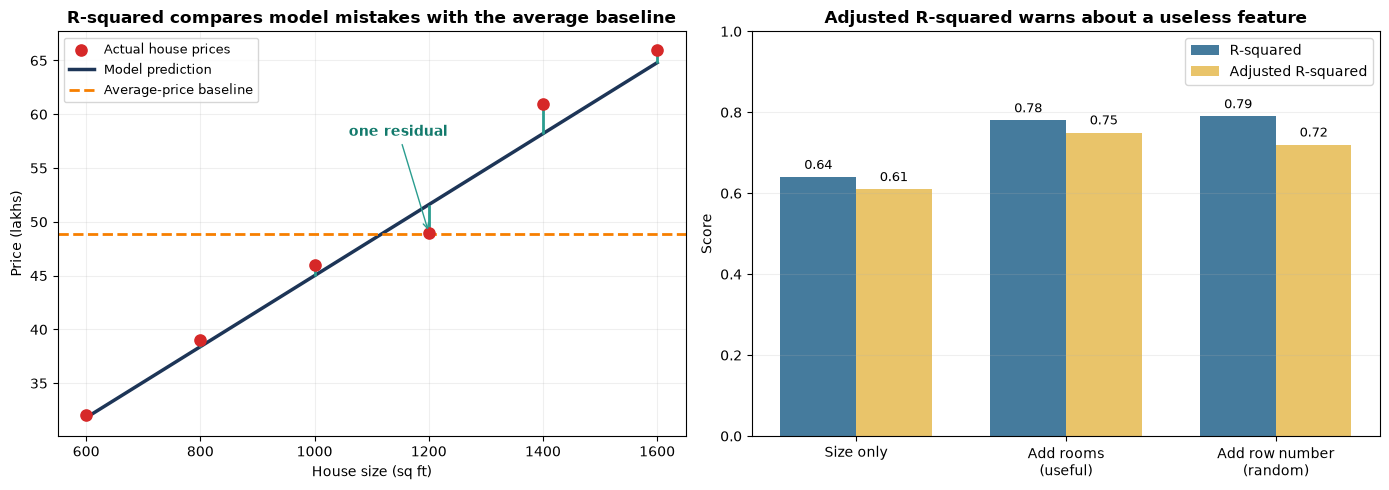

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Small toy example: house size and price
size = np.array([600, 800, 1000, 1200, 1400, 1600])
actual_price = np.array([32, 39, 46, 49, 61, 66])
predicted_price = 12 + 0.033 * size
average_price = actual_price.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: show actual values, predictions, residuals, and mean baseline
ax = axes[0]
ax.scatter(size, actual_price, color='#d62828', s=65, label='Actual house prices', zorder=3)
ax.plot(size, predicted_price, color='#1d3557', linewidth=2.5, label='Model prediction')
ax.axhline(average_price, color='#f77f00', linestyle='--', linewidth=2, label='Average-price baseline')
for x, real, pred in zip(size, actual_price, predicted_price):
    ax.vlines(x, min(real, pred), max(real, pred), color='#2a9d8f', linewidth=2)
ax.annotate('one residual', xy=(1200, 49), xytext=(1060, 58),
            arrowprops=dict(arrowstyle='->', color='#2a9d8f'), color='#137a6c', weight='bold')
ax.set_title('R-squared compares model mistakes with the average baseline', weight='bold')
ax.set_xlabel('House size (sq ft)')
ax.set_ylabel('Price (lakhs)')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Right: demonstrate the feature penalty idea
steps = ['Size only', 'Add rooms\n(useful)', 'Add row number\n(random)']
r_squared = [0.64, 0.78, 0.79]
adjusted_r_squared = [0.61, 0.75, 0.72]
x = np.arange(len(steps))
width = 0.36
bars1 = axes[1].bar(x - width/2, r_squared, width, label='R-squared', color='#457b9d')
bars2 = axes[1].bar(x + width/2, adjusted_r_squared, width, label='Adjusted R-squared', color='#e9c46a')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(x, steps)
axes[1].set_ylabel('Score')
axes[1].set_title('Adjusted R-squared warns about a useless feature', weight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.2)
for bars in [bars1, bars2]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## 6. Exam-ready recap

- Residual = real value minus predicted value.
- $R^2$ tells how much better the model is than predicting the average target value.
- Higher $R^2$ is usually better; it can also be negative.
- Ordinary $R^2$ does not punish useless features.
- Adjusted $R^2$ penalizes unnecessary features, so it is more useful for comparing multiple regression models.

**One-line answer:** Adjusted $R^2$ is like $R^2$, but it gives a penalty when we add input features that do not improve the model enough.